In [ ]:
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from dynamical_systems.continuous import Lorenz63, Lorenz96
from dynamical_systems.transforms import TransformedODE
from dynamics_discovery.data import TimeSeriesDataset
from einops import rearrange
from scipy.spatial import KDTree
from tqdm import tqdm


jax.config.update("jax_enable_x64", True)
plt.style.use("matplotlib_utils.styles.dash_gridded")

datadir = Path("../../data")

In [2]:
noise = 0.05
downsample = 2  # 2
dataset, transform = (
    TimeSeriesDataset(
        *TimeSeriesDataset.from_hdf5(datadir / "lorenz63_large.hdf5")[::100]
    )
    .downsample(downsample)
    # .split_along_time(2000)[0]
    .split_along_time(500)[0]
    .add_noise(noise)
    .standardize()
)

lorenz_scaled = TransformedODE(Lorenz63(), transform)

dataset.u.shape

(50, 500, 3)

In [ ]:
tree = KDTree(rearrange(dataset.u, "traj time dim -> (traj time) dim"))

r_max = 1.5
dist_mat = tree.sparse_distance_matrix(
    tree, max_distance=r_max, output_type="coo_matrix"
)

In [ ]:
neighbor_counts = []
neighbor_count_total = np.diff(dist_mat.indptr)
radii = np.arange(0.1, 1.5, 0.1)
for r in tqdm(radii):
    invalid_dists = dist_mat > r
    neighbor_counts.append(neighbor_count_total - np.diff(invalid_dists.indptr))

100%|██████████| 14/14 [00:11<00:00,  1.21it/s]


Text(0, 0.5, '# neighbors / # total points')

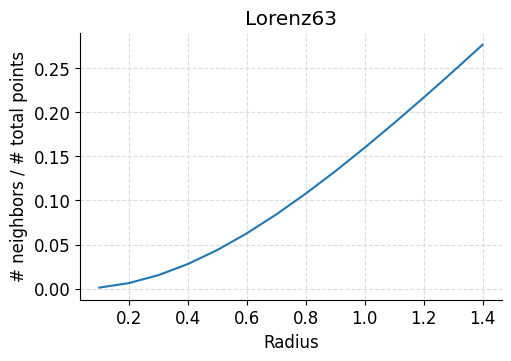

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), constrained_layout=True)
ax.plot(radii, np.mean(neighbor_counts, axis=1) / dist_mat.shape[1])
ax.set_title("Lorenz63")
ax.set_xlabel("Radius")
ax.set_ylabel("# neighbors / # total points")

## Repeat with Lorenz96

In [24]:
noise = 0.05
downsample = 2
dataset, transform = (
    TimeSeriesDataset(
        *TimeSeriesDataset.from_hdf5(datadir / "lorenz96_train.hdf5")[::100]
    )
    .downsample(downsample)
    .split_along_time(500)[0]
    .add_noise(noise)
    .standardize()
)

lorenz_scaled = TransformedODE(Lorenz96(), transform)

In [30]:
tree = KDTree(rearrange(dataset.u, "traj time dim -> (traj time) dim"))

r_max = 3.0
dist_mat = tree.sparse_distance_matrix(
    tree, max_distance=r_max, output_type="coo_matrix"
).tocsr()

In [33]:
neighbor_counts = []
neighbor_count_total = np.diff(dist_mat.indptr)
radii = np.arange(0.1, r_max, 0.1)
for r in tqdm(radii):
    invalid_dists = dist_mat > r
    neighbor_counts.append(neighbor_count_total - np.diff(invalid_dists.indptr))

100%|██████████| 29/29 [00:23<00:00,  1.21it/s]


Text(0, 0.5, '# neighbors / # total points')

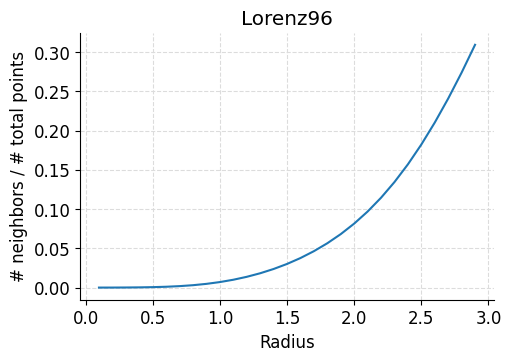

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), constrained_layout=True)
ax.plot(radii, np.mean(neighbor_counts, axis=1) / dist_mat.shape[1])
ax.set_title("Lorenz96")
ax.set_xlabel("Radius")
ax.set_ylabel("# neighbors / # total points")